# Blind Mystery test

## 1. Load 

In [77]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [78]:
# =========================================================
# PATHS
# =========================================================
BASE_DIR = Path(r"D:\Imperial-data\Data_Project\Project2")
MYSTERY_DIR = BASE_DIR / "Project_Vision_Data_Group_A" / "Mystery_Test_Set"
PRETRAINED_MODEL_PATH = BASE_DIR / "v3_best_model_both.pth"
REFERENCE_CSV_PATH = BASE_DIR / "AI.csv"

# threshold from pretrained notebook
PRETRAINED_THRESHOLD = 0.089

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Mystery folder exists:", MYSTERY_DIR.exists(), MYSTERY_DIR)
print("Pretrained model exists:", PRETRAINED_MODEL_PATH.exists(), PRETRAINED_MODEL_PATH)
print("Reference CSV exists:", REFERENCE_CSV_PATH.exists(), REFERENCE_CSV_PATH)

Device: cuda
Mystery folder exists: True D:\Imperial-data\Data_Project\Project2\Project_Vision_Data_Group_A\Mystery_Test_Set
Pretrained model exists: True D:\Imperial-data\Data_Project\Project2\v3_best_model_both.pth
Reference CSV exists: True D:\Imperial-data\Data_Project\Project2\AI.csv


In [79]:
# =========================================================
# DATASETS
# =========================================================
class MysteryDatasetCNN(Dataset):
    def __init__(self, folder_path):
        self.paths = sorted([
            p for p in Path(folder_path).iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        img = Image.open(img_path).convert("L")
        img = np.array(img, dtype=np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # (1, H, W)
        x = torch.from_numpy(img)
        return x, img_path.name


pretrained_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class MysteryDatasetPretrained(Dataset):
    def __init__(self, folder_path, transform):
        self.paths = sorted([
            p for p in Path(folder_path).iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        img = Image.open(img_path).convert("L")
        x = self.transform(img)
        return x, img_path.name

## Load Model

In [80]:
# =========================================================
# PRETRAINED MODEL
# =========================================================
def build_model(model_name: str = "resnet50", freeze_early: bool = True, out_features: int = 1):
    model_name = model_name.lower()

    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_feats = model.fc.in_features
        model.fc = nn.Linear(in_feats, out_features)

        if freeze_early:
            for block in [model.conv1, model.bn1, model.layer1]:
                for param in block.parameters():
                    param.requires_grad = False
    else:
        raise ValueError("Only resnet50 is supported here.")

    return model

In [81]:
# =========================================================
# DATASET FOR MYSTERY TEST SET
# =========================================================
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class MysteryDatasetPretrained(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = Path(folder_path)
        self.transform = transform
        
        self.image_paths = sorted([
            p for p in self.folder_path.iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        # read as RGB because pretrained ResNet expects 3 channels
        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, img_path.name

In [82]:
# =========================================================
# SAFE CHECKPOINT LOADER
# =========================================================
def load_model_weights(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

    if isinstance(checkpoint, dict):
        if "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        elif "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        else:
            state_dict = checkpoint
    else:
        raise ValueError(f"Unexpected checkpoint format: {type(checkpoint)}")

    cleaned_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            cleaned_state_dict[k[7:]] = v
        else:
            cleaned_state_dict[k] = v

    model.load_state_dict(cleaned_state_dict, strict=True)
    return model

In [83]:
# =========================================================
# PRETRAINED PREDICTION
# =========================================================
mystery_ds = MysteryDatasetPretrained(MYSTERY_DIR, transform=eval_transform)
mystery_dl = DataLoader(mystery_ds, batch_size=32, shuffle=False)

print("Number of mystery images:", len(mystery_ds))

pre_model = build_model("resnet50", freeze_early=True).to(device)
pre_model = load_model_weights(pre_model, PRETRAINED_MODEL_PATH, device)
pre_model.eval()

filenames = []
probabilities = []
predictions_num = []
predictions_text = []

with torch.no_grad():
    for images, names in mystery_dl:
        images = images.to(device)

        logits = pre_model(images)
        probs = torch.sigmoid(logits).squeeze(1)

        preds = (probs >= PRETRAINED_THRESHOLD).long()

        filenames.extend(list(names))
        probabilities.extend(probs.cpu().numpy().tolist())
        predictions_num.extend(preds.cpu().numpy().tolist())
        predictions_text.extend(["Cracked" if p == 1 else "Non-Cracked" for p in preds])

pretrained_pred_df = pd.DataFrame({
    "FileName": filenames,
    "Pretrained_Probability": probabilities,
    "Pretrained_Prediction_Num": predictions_num,
    "Pretrained_Prediction": predictions_text
})

print(pretrained_pred_df.head())
print()
print(pretrained_pred_df["Pretrained_Prediction"].value_counts())

Number of mystery images: 700
            FileName  Pretrained_Probability  Pretrained_Prediction_Num  \
0  img_test_0000.jpg            1.542443e-13                          0   
1  img_test_0001.jpg            2.812874e-02                          0   
2  img_test_0002.jpg            9.953715e-01                          1   
3  img_test_0003.jpg            4.714882e-03                          0   
4  img_test_0004.jpg            3.846715e-03                          0   

  Pretrained_Prediction  
0           Non-Cracked  
1           Non-Cracked  
2               Cracked  
3           Non-Cracked  
4           Non-Cracked  

Pretrained_Prediction
Non-Cracked    429
Cracked        271
Name: count, dtype: int64


## Test

In [84]:
# =========================================================
# SAVE PRETRAINED RESULTS
# =========================================================
pretrained_output_path = BASE_DIR / "pretrained_predictions.csv"
pretrained_pred_df.to_csv(pretrained_output_path, index=False)

print("Saved pretrained prediction CSV to:")
print(pretrained_output_path)

Saved pretrained prediction CSV to:
D:\Imperial-data\Data_Project\Project2\pretrained_predictions.csv


In [85]:
# =========================================================
# MERGE WITH EXISTING CSV
# =========================================================
ref_df = pd.read_csv(REFERENCE_CSV_PATH)

print("Reference CSV columns:", ref_df.columns.tolist())
print("Reference CSV shape:", ref_df.shape)

merged_df = ref_df.merge(pretrained_pred_df, on="FileName", how="outer")

merged_output_path = BASE_DIR / "blind_test_merged_with_pretrained.csv"
merged_df.to_csv(merged_output_path, index=False)

print("Saved merged CSV to:")
print(merged_output_path)
print()
print(merged_df.head())

Reference CSV columns: ['FileName', 'Prediction']
Reference CSV shape: (700, 2)
Saved merged CSV to:
D:\Imperial-data\Data_Project\Project2\blind_test_merged_with_pretrained.csv

            FileName   Prediction  Pretrained_Probability  \
0  img_test_0000.jpg  Non-Cracked            1.542443e-13   
1  img_test_0001.jpg      Cracked            2.812874e-02   
2  img_test_0002.jpg      Cracked            9.953715e-01   
3  img_test_0003.jpg  Non-Cracked            4.714882e-03   
4  img_test_0004.jpg  Non-Cracked            3.846715e-03   

   Pretrained_Prediction_Num Pretrained_Prediction  
0                          0           Non-Cracked  
1                          0           Non-Cracked  
2                          1               Cracked  
3                          0           Non-Cracked  
4                          0           Non-Cracked  


## Confusion Matrix

In [86]:
import pandas as pd

df = pd.read_csv(r"D:\Imperial-data\Data_Project\Project2\CNN_predictions.csv")

counts = df["Prediction"].value_counts()

num_cracked = counts.get("Cracked", 0)
num_noncracked = counts.get("Non-Cracked", 0)

print("Cracked:", num_cracked)
print("Non-Cracked:", num_noncracked)
print("Total:", num_cracked + num_noncracked)

Cracked: 292
Non-Cracked: 408
Total: 700


In [87]:
import pandas as pd

df = pd.read_csv(r"D:\Imperial-data\Data_Project\Project2\AI.csv")

counts = df["Prediction"].value_counts()

num_cracked = counts.get("Cracked", 0)
num_noncracked = counts.get("Non-Cracked", 0)

print("Cracked:", num_cracked)
print("Non-Cracked:", num_noncracked)
print("Total:", num_cracked + num_noncracked)

Cracked: 406
Non-Cracked: 294
Total: 700


In [88]:

import pandas as pd

df = pd.read_csv(r"D:\Imperial-data\Data_Project\Project2\pretrained_predictions.csv")

counts = df["Pretrained_Prediction"].value_counts()

num_cracked = counts.get("Cracked", 0)
num_noncracked = counts.get("Non-Cracked", 0)

print("Cracked:", num_cracked)
print("Non-Cracked:", num_noncracked)
print("Total:", num_cracked + num_noncracked)

Cracked: 271
Non-Cracked: 429
Total: 700


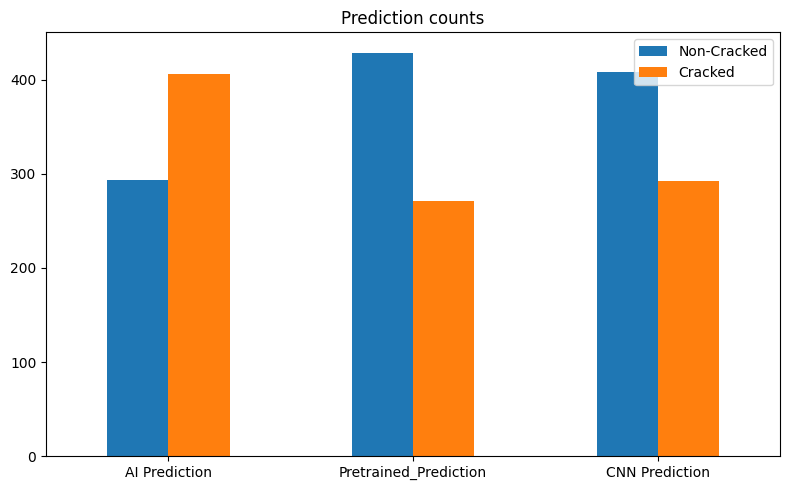

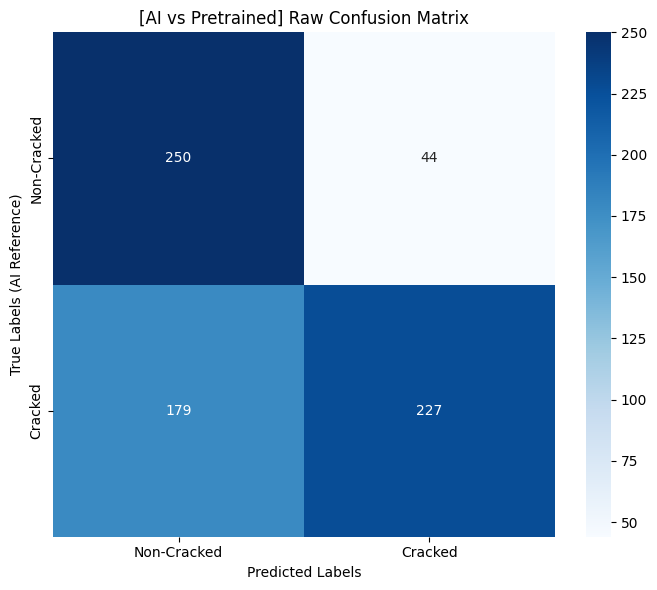

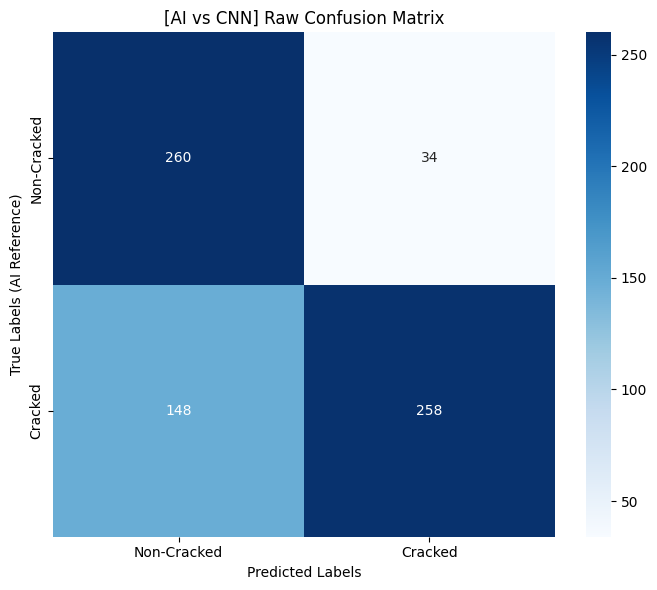

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

df = pd.read_csv(r"D:\Imperial-data\Data_Project\Project2\Blind_Test.csv")

mapping = {"Non-Cracked": 0, "Cracked": 1}

for col in ["AI Prediction", "Pretrained_Prediction", "CNN Prediction"]:
    df[col + "_num"] = df[col].map(mapping)

# counts
count_df = pd.DataFrame({
    col: df[col].value_counts().reindex(["Non-Cracked", "Cracked"], fill_value=0)
    for col in ["AI Prediction", "Pretrained_Prediction", "CNN Prediction"]
}).T

count_df.plot(kind="bar", figsize=(8, 5))
plt.title("Prediction counts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

def plot_confusion_matrix_sns(y_true, y_pred, title,
                              y_label="True Labels (Count)",
                              x_label="Predicted Labels"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    cm_df = pd.DataFrame(
        cm,
        index=["Non-Cracked", "Cracked"],
        columns=["Non-Cracked", "Cracked"]
    )

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True
    )
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

# AI vs Pretrained
plot_confusion_matrix_sns(
    df["AI Prediction_num"],
    df["Pretrained_Prediction_num"],
    "[AI vs Pretrained] Raw Confusion Matrix",
    y_label="True Labels (AI Reference)"
)

# AI vs CNN
plot_confusion_matrix_sns(
    df["AI Prediction_num"],
    df["CNN Prediction_num"],
    "[AI vs CNN] Raw Confusion Matrix",
    y_label="True Labels (AI Reference)"
)